# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Jonathan Federico Tantoro
- **Email:** cdcc014d6y2159@student.devacademy.id
- **ID Dicoding:** Jonathan Federico Tantoro

## Menentukan Pertanyaan Bisnis


1. Bagaimana pengaruh kondisi cuaca terhadap jumlah peminjaman sepeda?
    - Bagaimana hubungan suhu, kelembapan, dan kecepatan angin terhadap jumlah peminjaman?
    - Kondisi cuaca apa yang menghasilkan jumlah peminjaman tertinggi dan terendah?
2. Bagaimana pola peminjaman sepeda berdasarkan jam dalam sehari dan hari dalam seminggu?
   - Jam berapa peminjaman mencapai puncaknya dalam sehari?
   - Apakah pola berbeda antara hari kerja dan akhir pekan?


## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip freeze > requirements.txt

## Data Wrangling

### Gathering Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Bike Sharing Dataset/"

day_df  = pd.read_csv(path + 'day.csv')
hour_df = pd.read_csv(path + 'hour.csv')

Mounted at /content/drive


In [5]:
for name, df in {'day': day_df, 'hour': hour_df}.items():
    print(f'--- {name.upper()} ---')
    display(df.head())
    display(df.info())
    display(df.describe())


--- DAY ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


--- HOUR ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dataset ini berisikan peminjaman sepeda yang memiliki variasi tinggi yang dapat dilihat pada `describe()`
- Peminjaman sepeda paling banyak terjadi di hari kerja. Dapat dilihat di `workingday` bagian mean.
- Dataset berisikan berbagai kondisi lingkungan seperti `Temperature`, `Humidity`, `Windspeed`


### Assessing Data

In [6]:
for name, df in {'day': day_df, 'hour': hour_df}.items():
    print(f'--- {name.upper()} ---')
    print(f'Shape     : {df.shape}')
    print(f'Duplicates: {df.duplicated().sum()}')
    missing = df.isnull().sum()
    print(f'Missing   :\n{missing[missing > 0] if missing.any() else "Tidak ada"}')
    print()

--- DAY ---
Shape     : (731, 16)
Duplicates: 0
Missing   :
Tidak ada

--- HOUR ---
Shape     : (17379, 17)
Duplicates: 0
Missing   :
Tidak ada



**Insight:**
- Dataset tidak memiliki duplikat maupun missing values, sehingga dataset tidak memerlukan proses pembersihan lebih
- Dataset memiliki periode sekitar 2 tahun lebih dapat dilihat pada jumlah data di `Day`


### Cleaning Data

In [7]:
#Konversi kolom tanggal ke datetime
day_df['dteday']  = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [8]:
#Mapping nilai kategorikal
season_map = {1: 'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1: 'Clear', 2:'Cloudy', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}
weekday_map = {0: 'Sunday', 1: 'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'}

for df in [day_df, hour_df]:
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)

In [9]:
#mengubah scaling ke nilai asli
for df in [day_df, hour_df]:
    df['temp_actual']      = df['temp'] * 41        # °C
    df['hum_actual']       = df['hum'] * 100        # %
    df['windspeed_actual'] = df['windspeed'] * 67   # km/h


In [10]:
print('day_df  :', day_df.shape)
print('hour_df :', hour_df.shape)
print('\nSample day_df:')
display(day_df[['dteday','season_label','weather_label','temp_actual','hum_actual','cnt']].head())

day_df  : (731, 22)
hour_df : (17379, 23)

Sample day_df:


,dteday,season_label,weather_label,temp_actual,hum_actual,cnt
0,2011-01-01,Spring,Cloudy,14.110847,80.5833,985
1,2011-01-02,Spring,Cloudy,14.902598,69.6087,801
2,2011-01-03,Spring,Clear,8.050924,43.7273,1349
3,2011-01-04,Spring,Clear,8.200000,59.0435,1562
4,2011-01-05,Spring,Clear,9.305237,43.6957,1600


In [11]:
print(day_df['weathersit'].value_counts())

weathersit
1    463
2    247
3     21
Name: count, dtype: int64


In [12]:
#membuat main_data.csv untuk streamlit
day_df['source']  = 'day'
hour_df['source'] = 'hour'

main_data = pd.concat([day_df, hour_df], ignore_index=True)

# Simpan ke file
main_data.to_csv('main_data.csv', index=False)
print(f'main_data.csv berhasil dibuat: {main_data.shape}')
print(main_data.head())

main_data.csv berhasil dibuat: (18110, 24)
   instant     dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1 2011-01-01       1   0     1        0        6           0   
1        2 2011-01-02       1   0     1        0        0           0   
2        3 2011-01-03       1   0     1        0        1           1   
3        4 2011-01-04       1   0     1        0        2           1   
4        5 2011-01-05       1   0     1        0        3           1   

   weathersit      temp  ...  registered   cnt  season_label  weather_label  \
0           2  0.344167  ...         654   985        Spring         Cloudy   
1           2  0.363478  ...         670   801        Spring         Cloudy   
2           1  0.196364  ...        1229  1349        Spring          Clear   
3           1  0.200000  ...        1454  1562        Spring          Clear   
4           1  0.226957  ...        1518  1600        Spring          Clear   

   weekday_label  temp_actual hum_actual wi

**Insight:**
- Data diubah ke dalam format yang lebih mudah dimengerti seperti `dteday` diubah ke datetime dan `season`, `weathersit`, dan `weekday`di mapping
- Data cuaca sudah diubah menjadi nilai riil dari normalisasi
- Diketahui bahwa distribusi cuaca tidak merata karena mayoritas data cuaca "Clear" jauh lebih mendomninasi

## Exploratory Data Analysis (EDA)

### Explore Pengaruh Hubungan Kondisi Lingkungan Terhadap Jumlah Peminjaman

In [13]:
#menganalisis pengaruh kondisi cuaca terhadap jumlah peminjaman
weather_avg = day_df.groupby('weather_label')['cnt'].agg(
    avg_rentals = 'mean',
    total_rentals = 'sum',
    n_days = 'count'
).reset_index().sort_values('avg_rentals', ascending=False)

print('Rata-rata Peminjaman per Kondisi Cuaca:')
print(weather_avg.to_string(index=False))

Rata-rata Peminjaman per Kondisi Cuaca:
  weather_label  avg_rentals  total_rentals  n_days
          Clear  4876.786177        2257952     463
         Cloudy  4035.862348         996858     247
Light Rain/Snow  1803.285714          37869      21


In [14]:
#menganalisis pengaruh musim terhadap jumlah peminjaman
season_avg = day_df.groupby('season_label')['cnt'].agg(
    avg_rentals   = 'mean',
    total_rentals = 'sum',
    n_days        = 'count'
).reset_index().sort_values('avg_rentals', ascending=False)

print('Rata-rata Peminjaman per Musim:')
print(season_avg.to_string(index=False))

Rata-rata Peminjaman per Musim:
season_label  avg_rentals  total_rentals  n_days
        Fall  5644.303191        1061129     188
      Summer  4992.331522         918589     184
      Winter  4728.162921         841613     178
      Spring  2604.132597         471348     181


In [15]:
#korelasi suhu, kelembabpan, dan kecepatan angin dengan jumlah peminjaman
corr = day_df[['temp_actual', 'hum_actual', 'windspeed_actual', 'cnt']].corr()

print('Korelasi terhadap Jumlah Peminjaman:')
print(corr['cnt'].drop('cnt').round(3))

Korelasi terhadap Jumlah Peminjaman:
temp_actual         0.627
hum_actual         -0.101
windspeed_actual   -0.235
Name: cnt, dtype: float64


**Insight:**
- Cuaca sangat berpengaruh dalam jumlah peminjaman dimana semakin buruk cuaca maka semakin sedikit jumlah peminjaman yang terjadi
- Musim Fall dan Summer merupakan musim paling banyak jumlah peminjaman namun pada musim Spring jumlah peminjaman paling sedikit.
- Suhu merupakan faktor paling berpengaruh dalam jumlah peminjaman dimana semakin hangat suhu maka semakin banyak jumlah peminjaman. Sebaliknya faktor kelembapan dan kecepatan angin cenderung menurunkan jumlah peminjaman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap jumlah peminjaman sepeda?
  - Bagaimana hubungan suhu, kelembapan, dan kecepatan angin terhadap jumlah peminjaman?
  - Kondisi cuaca apa yang menghasilkan jumlah peminjaman tertinggi dan terendah?

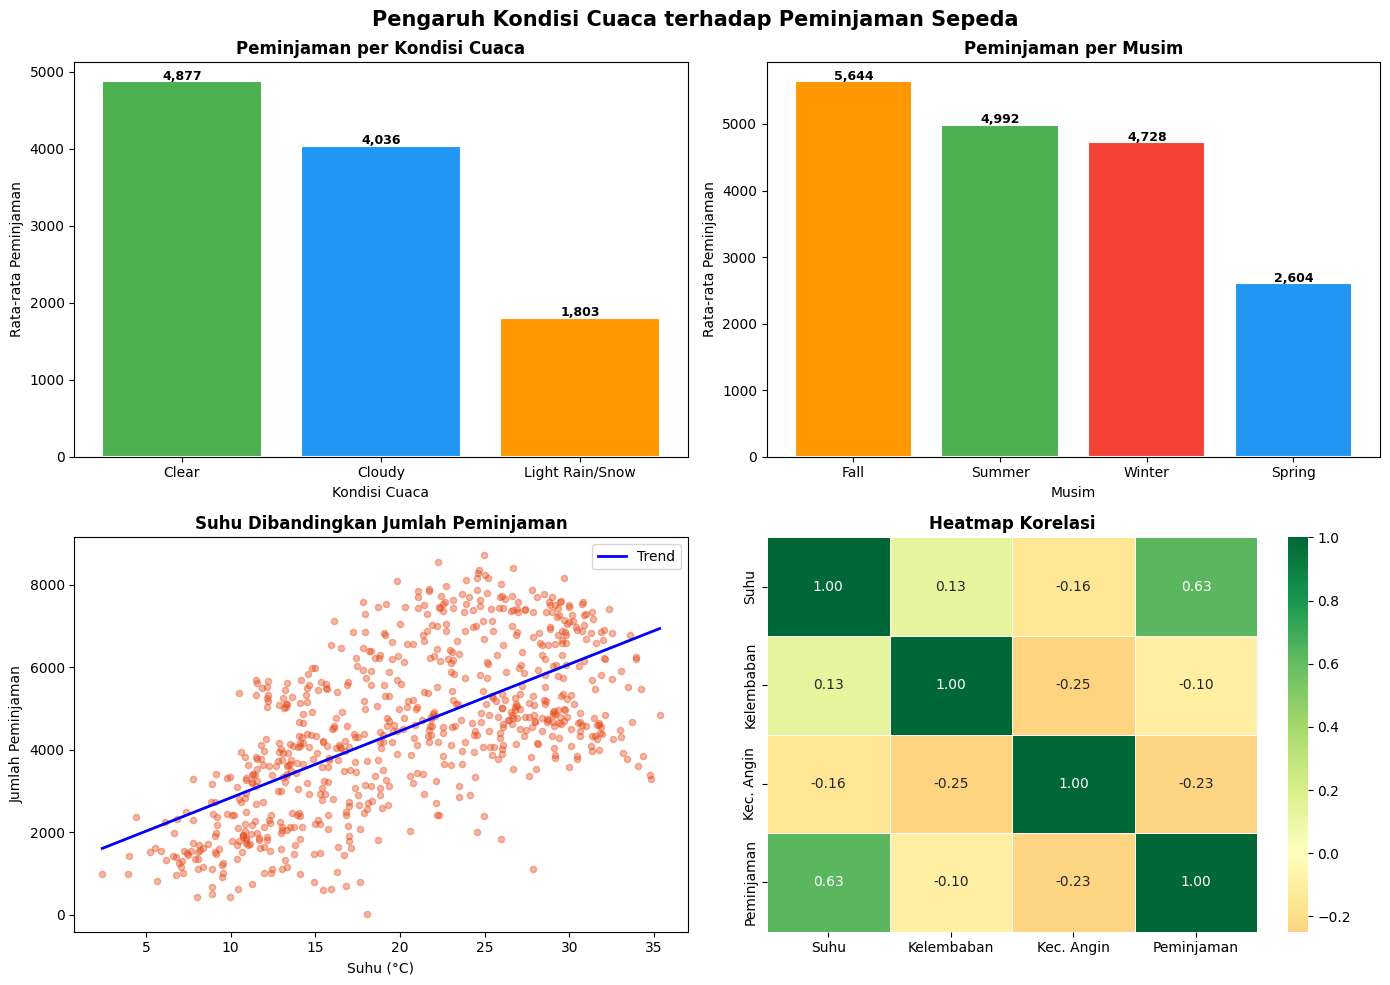

In [16]:
#visualisasi pengaruh cuaca
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pengaruh Kondisi Cuaca terhadap Peminjaman Sepeda',
             fontsize=15, fontweight='bold')

# Peminjaman per Kondisi Cuaca
ax1 = axes[0, 0]
colors_weather = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
bars1 = ax1.bar(weather_avg['weather_label'], weather_avg['avg_rentals'],
                color=colors_weather[:len(weather_avg)], edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Kondisi Cuaca')
ax1.set_ylabel('Rata-rata Peminjaman')
ax1.set_title('Peminjaman per Kondisi Cuaca', fontweight='bold')
for bar, val in zip(bars1, weather_avg['avg_rentals']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+20,
             f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Peminjaman per Musim
ax2 = axes[0, 1]
colors_season = ['#FF9800', '#4CAF50', '#F44336', '#2196F3']
bars2 = ax2.bar(season_avg['season_label'], season_avg['avg_rentals'],
                color=colors_season[:len(season_avg)], edgecolor='white', linewidth=1.5)
ax2.set_xlabel('Musim')
ax2.set_ylabel('Rata-rata Peminjaman')
ax2.set_title('Peminjaman per Musim', fontweight='bold')
for bar, val in zip(bars2, season_avg['avg_rentals']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+20,
             f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Scatter Plot Suhu(x) dan Jumlah Peminjaman(y)
ax3 = axes[1, 0]
ax3.scatter(day_df['temp_actual'], day_df['cnt'],
            alpha=0.4, color='#E64A19', s=20)
z = np.polyfit(day_df['temp_actual'], day_df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace(day_df['temp_actual'].min(), day_df['temp_actual'].max(), 100)
ax3.plot(x_line, p(x_line), 'b-', lw=2, label='Trend')
ax3.set_xlabel('Suhu (°C)')
ax3.set_ylabel('Jumlah Peminjaman')
ax3.set_title('Suhu Dibandingkan Jumlah Peminjaman', fontweight='bold')
ax3.legend()

# Heatmap Korelasi
ax4 = axes[1, 1]
corr_data = day_df[['temp_actual', 'hum_actual', 'windspeed_actual', 'cnt']].corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax4, linewidths=0.5,
            xticklabels=['Suhu', 'Kelembaban', 'Kec. Angin', 'Peminjaman'],
            yticklabels=['Suhu', 'Kelembaban', 'Kec. Angin', 'Peminjaman'])
ax4.set_title('Heatmap Korelasi', fontweight='bold')

plt.tight_layout()
plt.savefig('weather_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Pertanyaan 2: Bagaimana pola peminjaman sepeda berdasarkan jam dalam sehari dan hari dalam seminggu?
  - Jam berapa peminjaman mencapai puncaknya dalam sehari?
  - Apakah pola berbeda antara hari kerja dan akhir pekan?


In [17]:
# Pola Peminjaman per Jam & Hari

# Rata-rata peminjaman per jam
hourly_avg = hour_df.groupby('hr')['cnt'].mean().reset_index()
hourly_avg.columns = ['hour', 'avg_rentals']

print('Jam dengan Peminjaman Tertinggi:')
print(hourly_avg.nlargest(5, 'avg_rentals').to_string(index=False))

Jam dengan Peminjaman Tertinggi:
 hour  avg_rentals
   17   461.452055
   18   425.510989
    8   359.011004
   16   311.983562
   19   311.523352


In [18]:
# Rata-rata peminjaman per jam, dibedakan hari kerja vs akhir pekan
hourly_workday = hour_df.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()
hourly_workday.columns = ['hour', 'workingday', 'avg_rentals']
hourly_workday['day_type'] = hourly_workday['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan'})

print('Rata-rata Peminjaman per Jam (Hari Kerja vs Akhir Pekan):')
print(hourly_workday.head(10).to_string(index=False))


Rata-rata Peminjaman per Jam (Hari Kerja vs Akhir Pekan):
 hour  workingday  avg_rentals    day_type
    0           0    90.800000 Akhir Pekan
    0           1    36.786290  Hari Kerja
    1           0    69.508696 Akhir Pekan
    1           1    16.552632  Hari Kerja
    2           0    53.171053 Akhir Pekan
    2           1     8.683778  Hari Kerja
    3           0    25.775330 Akhir Pekan
    3           1     4.942553  Hari Kerja
    4           0     8.264317 Akhir Pekan
    4           1     5.429787  Hari Kerja


In [19]:
# Rata-rata peminjaman per hari dalam seminggu
weekday_avg = hour_df.groupby('weekday_label')['cnt'].mean().reset_index()
weekday_avg.columns = ['weekday', 'avg_rentals']

# Mengurutkan hari dan mengubah menjadi string
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_avg = weekday_avg.set_index('weekday').reindex(day_order).reset_index()
weekday_avg['weekday'] = weekday_avg['weekday'].astype(str)

print('Rata-rata Peminjaman per Hari:')
print(weekday_avg.to_string(index=False))

Rata-rata Peminjaman per Hari:
  weekday  avg_rentals
   Monday   183.744655
  Tuesday   191.238891
Wednesday   191.130505
 Thursday   196.436665
   Friday   196.135907
 Saturday   190.209793
   Sunday   177.468825


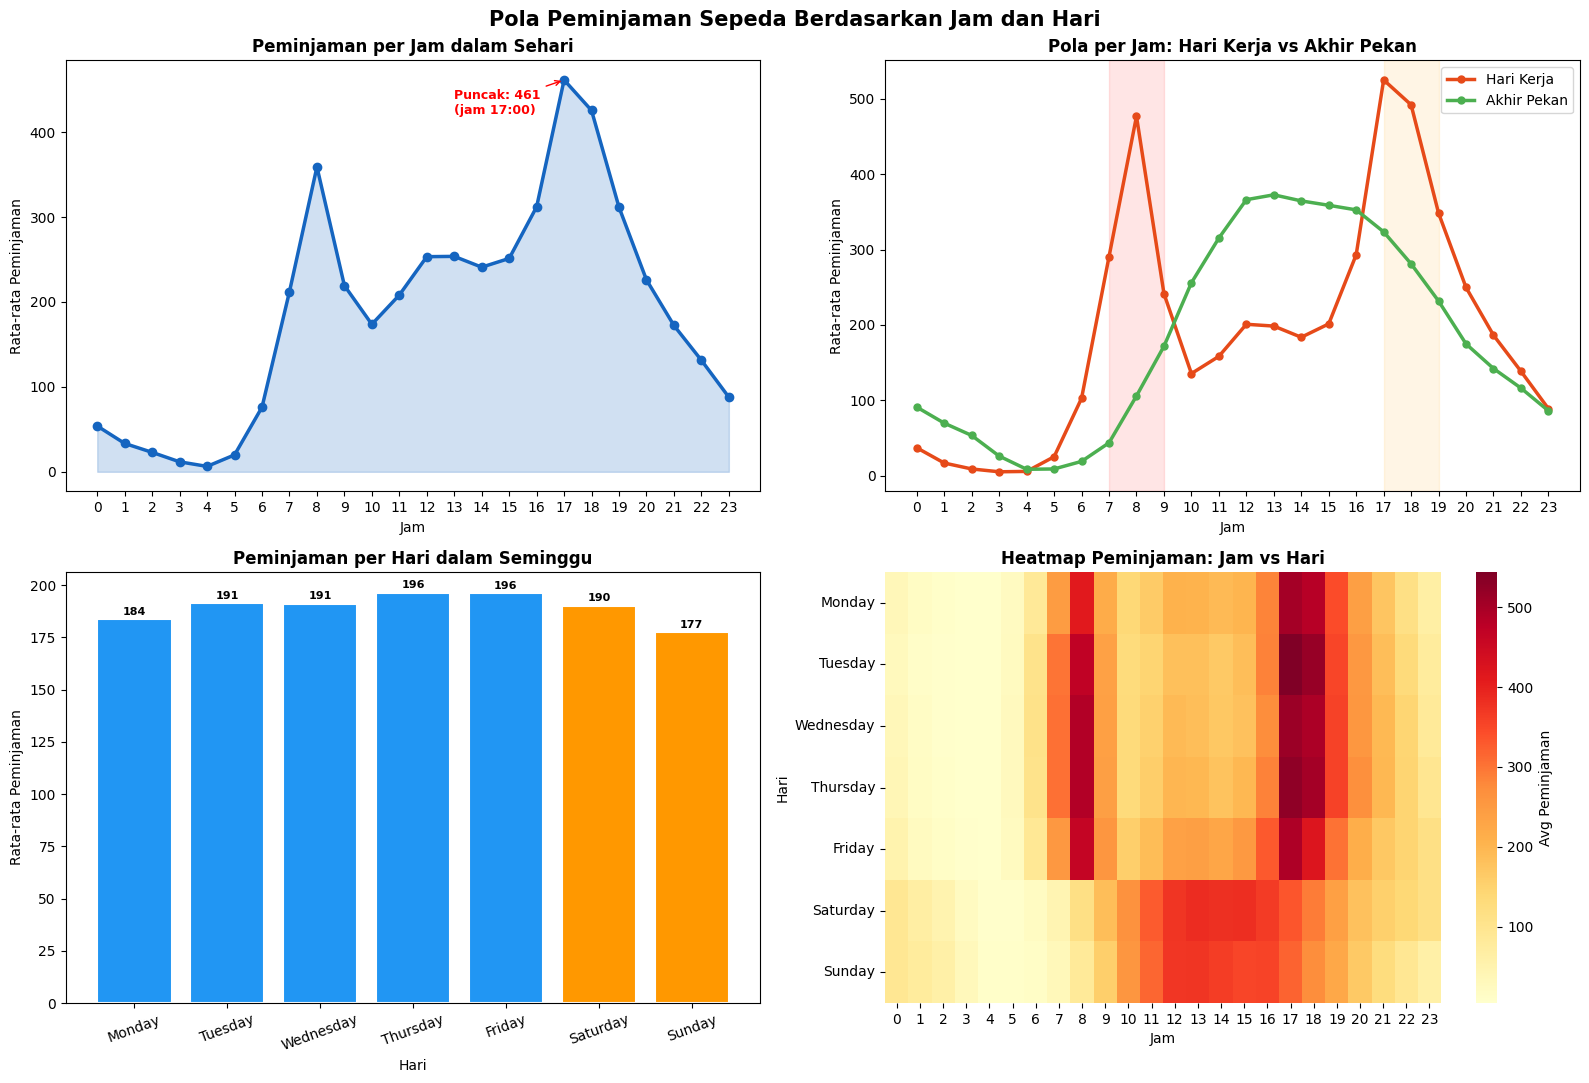

In [20]:
# Pola Per Jam & Hari

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Pola Peminjaman Sepeda Berdasarkan Jam dan Hari',
             fontsize=15, fontweight='bold')

# Peminjaman per Jam
ax1 = axes[0, 0]
ax1.plot(hourly_avg['hour'], hourly_avg['avg_rentals'],
         'o-', color='#1565C0', lw=2.5, ms=6)
ax1.fill_between(hourly_avg['hour'], hourly_avg['avg_rentals'],
                 alpha=0.2, color='#1565C0')
ax1.set_xticks(range(0, 24))
ax1.set_xlabel('Jam')
ax1.set_ylabel('Rata-rata Peminjaman')
ax1.set_title('Peminjaman per Jam dalam Sehari', fontweight='bold')
# Annotate puncak
peak_hour = hourly_avg.loc[hourly_avg['avg_rentals'].idxmax()]
ax1.annotate(f"Puncak: {peak_hour['avg_rentals']:.0f}\n(jam {int(peak_hour['hour'])}:00)",
             xy=(peak_hour['hour'], peak_hour['avg_rentals']),
             xytext=(peak_hour['hour']-4, peak_hour['avg_rentals']-40),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red', fontweight='bold')

# Hari Kerja vs Akhir Pekan per Jam
ax2 = axes[0, 1]
for day_type, color in [('Hari Kerja', '#E64A19'), ('Akhir Pekan', '#4CAF50')]:
    subset = hourly_workday[hourly_workday['day_type'] == day_type]
    ax2.plot(subset['hour'], subset['avg_rentals'],
             'o-', color=color, lw=2.5, ms=5, label=day_type)
ax2.set_xticks(range(0, 24))
ax2.set_xlabel('Jam')
ax2.set_ylabel('Rata-rata Peminjaman')
ax2.set_title('Pola per Jam: Hari Kerja vs Akhir Pekan', fontweight='bold')
ax2.legend()
ax2.axvspan(7, 9,   alpha=0.1, color='red',   label='Rush hour pagi')
ax2.axvspan(17, 19, alpha=0.1, color='orange', label='Rush hour sore')

# Peminjaman per Hari
ax3 = axes[1, 0]
colors_day = ['#2196F3','#2196F3','#2196F3','#2196F3','#2196F3','#FF9800','#FF9800']
bars3 = ax3.bar(weekday_avg['weekday'], weekday_avg['avg_rentals'],
                color=colors_day, edgecolor='white', linewidth=1.5)
ax3.set_xlabel('Hari')
ax3.set_ylabel('Rata-rata Peminjaman')
ax3.set_title('Peminjaman per Hari dalam Seminggu', fontweight='bold')
ax3.tick_params(axis='x', rotation=20)
for bar, val in zip(bars3, weekday_avg['avg_rentals']):
    ax3.text(bar.get_x()+bar.get_width()/2, val+2,
             f'{val:.0f}', ha='center', fontsize=8, fontweight='bold')

# -- Plot 4: Heatmap Jam vs Hari --
ax4 = axes[1, 1]
heatmap_data = hour_df.groupby(['weekday_label', 'hr'])['cnt'].mean().unstack()
heatmap_data = heatmap_data.reindex(day_order)
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax4,
            cbar_kws={'label': 'Avg Peminjaman'})
ax4.set_xlabel('Jam')
ax4.set_ylabel('Hari')
ax4.set_title('Heatmap Peminjaman: Jam vs Hari', fontweight='bold')

plt.tight_layout()
plt.savefig('hourly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Cuaca Clear memiliki hasil tertinggi ini membuktikan bahwa cuaca memiliki pengaruh besar dalam jumlah peminjaman
- Jumlah peminjaman juga terpengaruh dari jumlah musim dengan musim Fall yang paling tinggi.
- Semakin tinggi suhu maka semakin banyak peminjaman terjadi
- Terdapat dua jam yang memiliki jumlah peminjaman tertinggi yakni pada pagi hari di pukul 08:00 dan sore hari pukul 17:00.
- Hari kerja memiliki dua puncak peminjaman yang mendominasi sedangkan pada akhir pekan pola peminjaman lebih merata.


## Analisis Lanjutan (Opsional)

Pada proyek ini menggunakan teknik analisis lanjutan yakni Clustering (Manual Grouping dan Binning).
Tujuan dari teknik ini adapun:
1. Manual Grouping:
  - Mengelompokkan 24 jam ke dalam cluster berdasarkan tingkat kesibukan peminjaman. Dengan adanya cluster ini identifikasi jumlah permintaan sepeda dapat dilihat jelas dimana peak dan low nya. sehingga pemilik rental sepeda dapat melakukan penambahan jumlah sepeda pada jam peak, dan melakukan perawatan sepeda pada jam low. Serta dapat menentukan penyesuaian harga atau promo berdasarkan tingkat kesibukan yang ada.

2. Binning
  - Suhu dikategorikan ke dalam 4 kelompok untuk mengidentifikasi pada kondisi suhu apa jumlah peminjaman sepeda paling tinggi maupun rendah. dengan adanya pengelompokkan ini pemilik rental sepeda dapat mengetahui kapan menentukan kondisi operasional ideal untuk membuka layanan

In [21]:
def cluster_hour(hour):
    if hour in [0,1,2,3,4,5]:        return 'Low (Dini Hari)'
    elif hour in [6,7,8,9]:           return 'Peak (Rush Pagi)'
    elif hour in [10,11,12,13,14,15]: return 'Medium (Siang)'
    elif hour in [16,17,18,19]:       return 'Peak (Rush Sore)'
    else:                             return 'Low (Malam)'

hour_df['hour_cluster'] = hour_df['hr'].apply(cluster_hour)

cluster_avg = hour_df.groupby('hour_cluster')['cnt'].agg(
    avg_rentals = 'mean',
    total_rentals = 'sum'
).reset_index().sort_values('avg_rentals', ascending=False)

print('Rata-rata Peminjaman per Cluster Jam:')
print(cluster_avg.to_string(index=False))

Rata-rata Peminjaman per Cluster Jam:
    hour_cluster  avg_rentals  total_rentals
Peak (Rush Sore)   377.629973        1101169
  Medium (Siang)   230.192493        1005711
Peak (Rush Pagi)   216.704061         629742
     Low (Malam)   154.377747         449548
 Low (Dini Hari)    24.908559         106509


In [22]:
day_df['temp_bin'] = pd.cut(
    day_df['temp_actual'],
    bins=[0, 10, 20, 30, 41],
    labels=['Dingin (0-10°C)', 'Sejuk (10-20°C)',
            'Hangat (20-30°C)', 'Panas (30-41°C)']
)

temp_bin_avg = day_df.groupby('temp_bin', observed=True)['cnt'].agg(
    avg_rentals   = 'mean',
    total_rentals = 'sum',
    n_days        = 'count'
).reset_index()

print('Rata-rata Peminjaman per Kelompok Suhu:')
print(temp_bin_avg.to_string(index=False))

Rata-rata Peminjaman per Kelompok Suhu:
        temp_bin  avg_rentals  total_rentals  n_days
 Dingin (0-10°C)  1677.766667         100666      60
 Sejuk (10-20°C)  3692.274247        1103990     299
Hangat (20-30°C)  5661.686667        1698506     300
 Panas (30-41°C)  5409.958333         389517      72


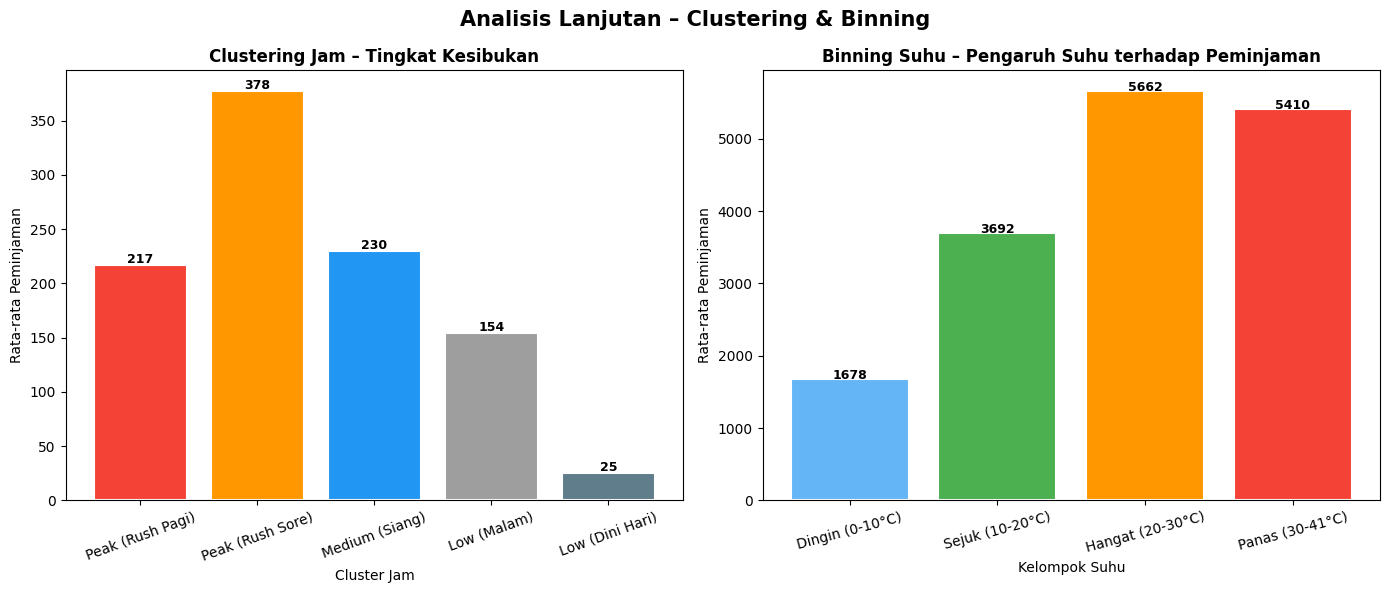

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis Lanjutan – Clustering & Binning',
             fontsize=15, fontweight='bold')

#Clustering Jam
ax1 = axes[0]
cluster_order = ['Peak (Rush Pagi)', 'Peak (Rush Sore)',
                 'Medium (Siang)', 'Low (Malam)', 'Low (Dini Hari)']
cluster_colors = ['#F44336', '#FF9800', '#2196F3', '#9E9E9E', '#607D8B']
cluster_plot = cluster_avg.set_index('hour_cluster').reindex(cluster_order).reset_index()

bars1 = ax1.bar(cluster_plot['hour_cluster'], cluster_plot['avg_rentals'],
                color=cluster_colors, edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Cluster Jam')
ax1.set_ylabel('Rata-rata Peminjaman')
ax1.set_title('Clustering Jam – Tingkat Kesibukan', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
for bar, val in zip(bars1, cluster_plot['avg_rentals']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+2,
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

# Binning Suhu
ax2 = axes[1]
temp_colors = ['#64B5F6', '#4CAF50', '#FF9800', '#F44336']
bars2 = ax2.bar(temp_bin_avg['temp_bin'].astype(str), temp_bin_avg['avg_rentals'],
                color=temp_colors, edgecolor='white', linewidth=1.5)
ax2.set_xlabel('Kelompok Suhu')
ax2.set_ylabel('Rata-rata Peminjaman')
ax2.set_title('Binning Suhu – Pengaruh Suhu terhadap Peminjaman', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, temp_bin_avg['avg_rentals']):
    ax2.text(bar.get_x()+bar.get_width()/2, val+2,
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('advanced_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

- Conclution pertanyaan 1:
Pengaruh kondisi cuaca terhadap jumlah peminjaman sepeda
    - Cuaca "Clear" menghasilkan rata-rata peminjaman tertinggi, sedangkan cuaca "hujan/salju lebat (Heavy Rain/Snow)" paling rendah karena tidak ditemukan jumlah peminjaman.
    - Suhu memiliki hubungan positif terhadap jumlah peminjaman dimana jika suhu semakin hangat maka semakin banyak jumlah peminjaman sepeda.
    - Kelembapan memiliki hubungan negatif dimana jika semakin lembap maka jumlah peminjaman menurun.
    - Musim "Fall" merupakan musim dengan rata-rata peminjaman tertinggi, sedangkan musim "Spring" merupakan yang terendah.  
- Conclution pertanyaan 2:
Pola peminjaman sepeda berdasarkan jam dalam sehari dan hari dalam seminggu
    - Puncak peminjaman terjadi pada sore hari pukul 17:00. sedangkan posisi kedua terbanyak pada pagi hari pukul 08:00 dan peminjaman terendah pada pukul 04:00.
    - Peminjaman relatif stabil pada hari kerja (senin - jumat). dengan hari kamis dan jumat merupakan peminjaman tertinggi. Hari dengan jumlah peminjaman terendah terjadi pada hari minggu.
    - Perbedaan pola pada hari kerja dan akhir pekan dapat terlihat karena pada hari kerja terdapat dua jam padat yang mendominasi sedangkan pada akhir pekan tidak ada puncak peminjaman yang signifikan di pagi maupun sore hari